# 高息价值池 × 唐奇安 20/10 突破策略

**策略概览**（代码：池 `screener/dividend_value.py`，回测 `strategy/donchian_value_strategy.py`，一键复现 `scripts/run_donchian_value_backtest.py`）：

- **标的池**：每月首个交易日按市值 Top300 预筛，4 因子选 3 —— 股息率>4% / PE_TTM<20 / ROE 连续三年>10% / 市值>500 亿（全部 point-in-time、公告可见口径）
- **入场**：池内成员收盘价突破 20 日最高（前一日）→ 买入至目标权重 5%
- **出场**：持仓收盘价跌破 10 日最低（前一日）→ 清仓（唐奇安离场）
- **月度再平衡**：跌出池 → 清仓；权重 > 5% → 减持回落至 5%
- **成本**：买卖佣金万 3，卖出印花税万 5
- **资金**：初始 100 万；回测区间 2023-01 ~ 数据末端
- **已知局限**：分红现金未建模（用不复权收盘价，长期 NAV 略被低估）

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')
_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, 'strategy', 'donchian_value_strategy.py')): break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT); sys.path.insert(0, _ROOT)
from screener.dividend_value import build_value_screener, stock_name
from data.local import load_market_frames
from backtest.donchian import DonchianValueStrategy
from backtest.multifactor import perf_summary
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'Arial Unicode MS', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
START = pd.Timestamp('2023-01-01')
INITIAL_CAPITAL = 1_000_000.0

## 构造池并集并预加载行情

In [2]:
screener = build_value_screener(top_n=300)

# 月度首个交易日（以格力日线为交易日历代理；策略内部会按自身市场日历重构）
cal = pd.read_csv('data/000651_market.csv', index_col='date', parse_dates=True).index
month_start = {}
for d in cal:
    if d < START: continue
    month_start.setdefault((d.year, d.month), d)

union = set()
for rep in sorted(month_start.values()):
    union |= {c for c, d in screener(rep).items() if d['pass']}

mkt = load_market_frames(sorted(union) + ['512890', '510880', '000300'], 'data', min_rows=1)
print(f'池并集 {len(union)} 只, 加载行情 {len(mkt)} 只')

print('逐月池规模（每年 1 月）:')
for k, rep in sorted(month_start.items()):
    if rep.month == 1:
        n = sum(1 for c, d in screener(rep).items() if d['pass'])
        print(f'  {rep.year}-{rep.month:02d}: {n} 只')

池并集 142 只, 加载行情 145 只
逐月池规模（每年 1 月）:
  2023-01: 44 只
  2024-01: 51 只
  2025-01: 42 只
  2026-01: 46 只


## 运行回测

In [3]:
strat = DonchianValueStrategy(screener, initial_capital=INITIAL_CAPITAL)
nav_abs = strat.run(mkt, start_date=str(START.date()))['nav']
nav = nav_abs / nav_abs.iloc[0]
print(f'回测 {nav.index[0].date()} ~ {nav.index[-1].date()}, '
      f'期末净值 {nav_abs.iloc[-1]:,.0f} ({(nav.iloc[-1]-1):+.1%})')

回测 2023-01-03 ~ 2026-08-21, 期末净值 1,442,937 (+44.3%)


## 基准对比（绩效表）

In [4]:
BENCH = {'512890': '红利低波ETF', '510880': '红利ETF', '000300': '沪深300'}
navs = {'高息价值×唐奇安(含成本)': nav}
for code, label in BENCH.items():
    df = mkt[code][mkt[code].index >= START]
    if df.empty: continue
    navs[label] = df['close'] / df['close'].iloc[0]

rows = {}
for label, n in navs.items():
    s = perf_summary(n.dropna())
    s['期末权益(¥)'] = f'{n.dropna().iloc[-1] * INITIAL_CAPITAL:,.0f}'
    rows[label] = s
pd.DataFrame(rows).T

,total_return,annual_return,annual_vol,sharpe,calmar,max_drawdown,win_rate,n_trading_days,期末权益(¥)
高息价值×唐奇安(含成本),44.29%,10.63%,15.17%,0.57,0.47,-18.49%,49.89%,880,"1,442,937"
红利低波ETF,41.35%,10.07%,13.42%,0.60,0.58,-14.01%,50.34%,874,"1,413,497"
红利ETF,42.17%,10.24%,14.77%,0.56,0.54,-15.14%,52.40%,874,"1,421,739"
沪深300,34.62%,11.90%,18.84%,0.53,0.63,-15.66%,51.96%,639,"1,346,182"


## 净值曲线

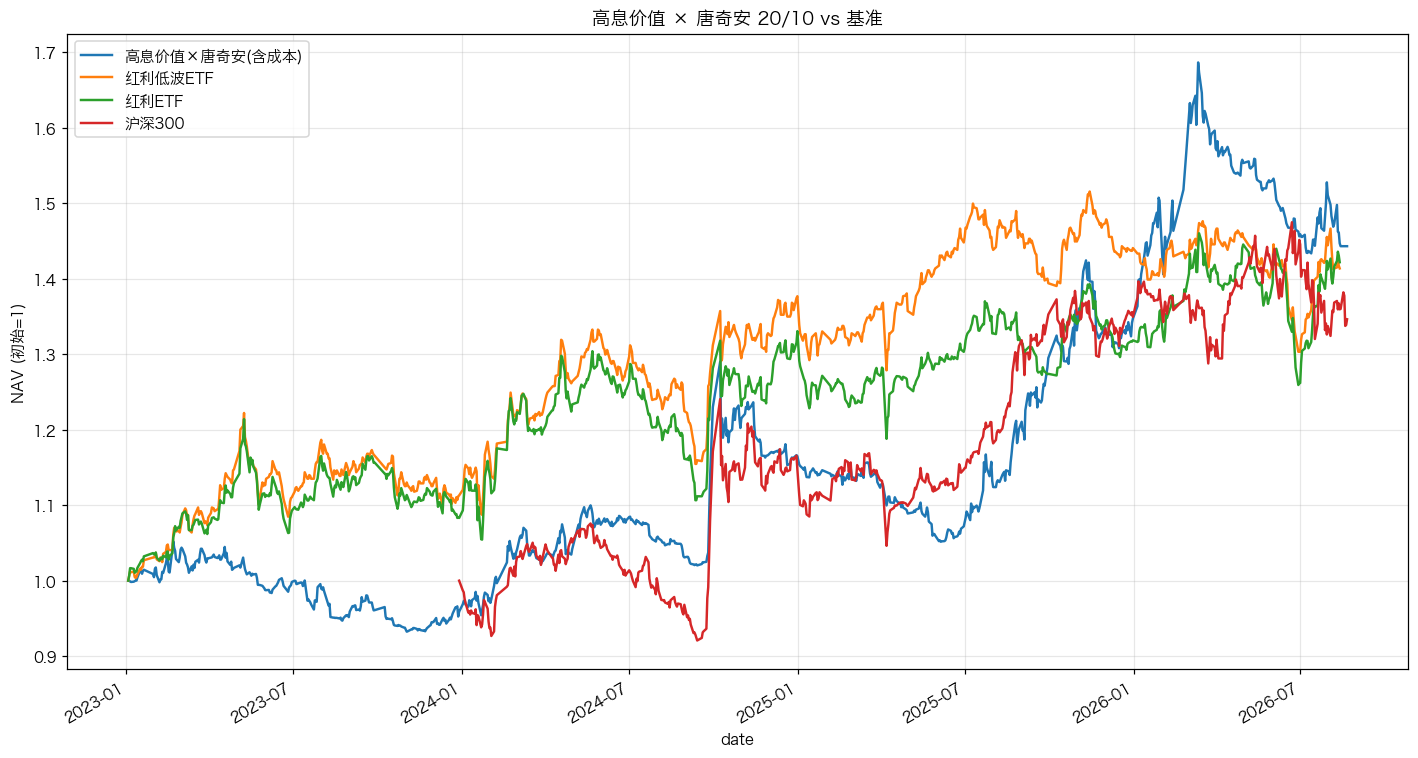

In [5]:
fig, ax = plt.subplots(figsize=(13, 7))
for label, n in navs.items():
    n.dropna().plot(ax=ax, label=label, linewidth=1.6)
ax.set_title('高息价值 × 唐奇安 20/10 vs 基准')
ax.set_ylabel('NAV (初始=1)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## 池成分示例（首个交易日）

In [6]:
for k in [(2023, 7), (2025, 7)]:
    rep = month_start[k]
    detail = {c: d for c, d in screener(rep).items() if d['pass']}
    df = pd.DataFrame(detail).T
    df['name'] = [stock_name(c) for c in df.index]
    df = df[['name', 'mc_yi', 'div_yield', 'pe_ttm']].sort_values('mc_yi', ascending=False)
    print(f'== 池 @ {rep.date()} 首个交易日 ({len(df)} 只) ==')
    print(df.head(12).to_string(index=True))
    print()

== 池 @ 2023-07-03 首个交易日 (46 只) ==
         name        mc_yi div_yield     pe_ttm
601088   中国神华    6191.1804  0.081836  10.775703
600900   长江电力  5234.428502  0.036858  19.744617
000333   美的集团  4148.490748   0.04233  14.166897
002415   海康威视  3127.553552  0.020958  18.490122
600309   万华化学  2749.790095  0.018269   11.75055
601668   中国建筑  2423.810227   0.04372   4.532406
600690   海尔智家  2201.057449  0.019801  16.243342
000651   格力电器  2106.145747  0.026738   8.915224
600887   伊利股份  1864.005023  0.035702  19.844097
601225   陕西煤业     1799.392  0.072737   7.406168
000002  万  科Ａ   1688.19539  0.068984   7.449769
600104   上汽集团  1668.398283  0.047759   7.190693

== 池 @ 2025-07-01 首个交易日 (53 只) ==
         name        mc_yi div_yield     pe_ttm
600938   中国海油    19644.534  0.025891  14.944605
601088   中国神华    8134.3686  0.055203  14.618065
000333   美的集团  5523.882712  0.048537  15.929029
000858  五 粮 液  4604.751576  0.039366  15.242179
601138   工业富联  4249.796682  0.027103  19.232715
000651   格力电器  2545

## 交易统计

In [7]:
tl = strat.portfolio.trade_log
buys = [t for t in tl if t['action'] == 'buy']
sells = [t for t in tl if t['action'] == 'sell']
by_reason = pd.Series([t['reason'] for t in sells]).value_counts()
print(f'买入 {len(buys)} 笔, 卖出 {len(sells)} 笔, 合计 {len(tl)} 笔')
print('离场原因分布:'); print(by_reason.to_string())

buy_amt = sum(t['amount'] for t in buys)
years = (nav.index[-1] - nav.index[0]).days / 365.25
print(f'\n年均单边换手 ≈ {buy_amt / years / INITIAL_CAPITAL:.2f} 倍')

买入 528 笔, 卖出 629 笔, 合计 1157 笔
离场原因分布:
donchian_exit     426
rebalance_trim    117
pool_exit          86

年均单边换手 ≈ 8.17 倍


## 个股趋势与买卖点

In [10]:
from screener.dividend_value import stock_name
from collections import deque

# 按首次交易时间排序，竖排一列往下排
traded_codes = sorted({t['code'] for t in tl}, key=lambda c: min(t['date'] for t in tl if t['code'] == c))
pnl_rows = []

n_stocks = len(traded_codes)
ncols, nrows = 1, n_stocks

fig, axes = plt.subplots(nrows, 1, figsize=(12, 3.2 * nrows), squeeze=False)
fig.suptitle('持仓个股趋势 × 买卖点标记（竖排·时间序）', fontsize=16, fontweight='bold', y=0.99)

for idx, code in enumerate(traded_codes):
    ax = axes[idx][0]

    # 该股票的行情数据
    if code not in mkt:
        ax.set_visible(False)
        continue
    df = mkt[code]
    df_range = df[df.index >= START]
    if df_range.empty:
        ax.set_visible(False)
        continue

    # 绘制收盘价
    ax.plot(df_range.index, df_range['close'], color='#1f77b4', linewidth=0.9)

    # 该股买卖按时间排序，卖出用FIFO配对算已实现盈亏
    buys_t = sorted([t for t in tl if t['code'] == code and t['action'] == 'buy'], key=lambda x: x['date'])
    sells_t = sorted([t for t in tl if t['code'] == code and t['action'] == 'sell'], key=lambda x: x['date'])
    lots = deque([[t['shares'], t['price'] + t['fees'] / t['shares']] for t in buys_t])
    tot_pnl = 0.0
    for s in sells_t:
        need = s['shares']
        spnl = 0.0
        while need > 1e-9 and lots:
            q, c = lots[0]
            m = min(q, need)
            spnl += m * s['price'] - m * c - s['fees'] * m / s['shares']
            q -= m
            need -= m
            lots.popleft() if q <= 1e-9 else lots.__setitem__(0, [q, c])
        tot_pnl += spnl
        pnl_rows.append({'code': code, 'name': stock_name(code), 'sell_date': s['date'], 'price': s['price'], 'shares': s['shares'], 'pnl': round(spnl, 2), 'reason': s.get('reason', '')})

    # 标记买入点
    if buys_t:
        buy_dates = [t['date'] for t in buys_t]
        buy_prices = [t['price'] for t in buys_t]
        ax.scatter(buy_dates, buy_prices, marker='^', color='#2ca02c',
                   s=40, zorder=5, label='买入')

    # 标记卖出点
    if sells_t:
        sell_dates = [t['date'] for t in sells_t]
        sell_prices = [t['price'] for t in sells_t]
        ax.scatter(sell_dates, sell_prices, marker='v', color='#d62728',
                   s=40, zorder=5, label='卖出')

    name = stock_name(code)
    ax.set_title(f'{name} ({code}) 累计实现 {tot_pnl:+.0f}', fontsize=10)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# 隐藏多余子图
for idx in range(n_stocks, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row][col].set_visible(False)

# 统一图例
handles = [plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#2ca02c', markersize=8, label='买入'),
           plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='#d62728', markersize=8, label='卖出')]
fig.legend(handles=handles, loc='upper right', fontsize=10, ncol=2,
           bbox_to_anchor=(0.98, 1.0))

plt.tight_layout()
plt.show()
print(f'共 {n_stocks} 只股票')
pnl_df = pd.DataFrame(pnl_rows).sort_values('sell_date') if pnl_rows else pd.DataFrame()
print(pnl_df.to_string(index=False))

共 124 只股票
  code  name  sell_date  price  shares       pnl         reason
600039  四川路桥 2023-02-01  12.18    4400   3726.18      pool_exit
000425  徐工机械 2023-02-01   5.90    9000   3452.64      pool_exit
600256  广汇能源 2023-02-01  10.24    4800   -534.21      pool_exit
000725  京东方Ａ 2023-02-01   4.05     400     70.24 rebalance_trim
000338  潍柴动力 2023-02-01  11.50     100     51.75 rebalance_trim
601857  中国石油 2023-02-01   5.20    9700     41.55      pool_exit
000661  长春高新 2023-02-01 203.00     200   2426.08      pool_exit
000333  美的集团 2023-02-02  53.96     800  -1639.96  donchian_exit
601225  陕西煤业 2023-02-06  19.09    2500  -1402.90  donchian_exit
000651  格力电器 2023-02-06  33.84    1400   -556.26  donchian_exit
600690  海尔智家 2023-02-06  25.49    1900   -471.40  donchian_exit
000895  双汇发展 2023-02-06  25.16    1900  -2067.19  donchian_exit
601088  中国神华 2023-02-08  27.91    1700  -1871.74  donchian_exit
002601  龙佰集团 2023-02-16  21.19    2200  -3176.22  donchian_exit
600663   陆家嘴 2023-02-16   9.96